# Los "forever chemicals" ahora fabrican baterías

Los PFAS llevan décadas contaminando agua, suelo y sangre. Son tan estables que los llaman *forever chemicals*: nadie puede destruirlos. Hasta ahora, todo el esfuerzo iba a degradarlos. ¿Y si en vez de destruirlos, los convertimos en algo útil?

---

**Paper:** Electrothermal fluorination of PFAS for lithium recovery from brine \
**Journal:** Nature Water \
**DOI:** [10.1038/s44221-026-00593-1](https://doi.org/10.1038/s44221-026-00593-1)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-17-pfas-fabrican-baterias-litio/notebook.ipynb)
· [▶️ Ver video](https://youtube.com/watch?v=jJeBEpjSmww)

## La idea: usar el flúor del contaminante

Los PFAS (sustancias perfluoroalquiladas) están en espumas contra incendios, sartenes antiadherentes y mil productos más. Contaminan el agua de millones de personas. El problema es que su enlace C-F es uno de los más fuertes de la química orgánica — por eso no se degradan.

Pero ese mismo flúor es valioso. El equipo de Rice University hizo algo radical: usar fluorinación electrotérmica para arrancar el flúor de los PFAS y usarlo para convertir cloruros metálicos de salmueras en fluoruros. El producto estrella: **fluoruro de litio (LiF)**, con pureza del 99% y rendimiento del ~82% (etapa de lavado: ~86%).

De paso, el carbón activado (GAC) que absorbía los PFAS se convierte en **grafeno**. Dos problemas resueltos con un solo proceso.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
VOLTAJE_PROCESO = 100        # V — voltaje usado en el paper
TEMP_CRITICA = 200           # °C — donde LiCl ΔG se vuelve negativa
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-03-17-pfas-fabrican-baterias-litio'
FUENTE = 'Fuente: Yang et al. (2026), Nature Water | DOI: 10.1038/s44221-026-00593-1'
COLOR_LITIO = '#2563EB'      # Azul CaM — litio / datos principales
COLOR_ALERTA = '#DC2626'     # Rojo — PFAS / alerta
COLOR_SODIO = '#D97706'      # Amber — sodio / referencia
COLOR_POTASIO = '#7C3AED'    # Violeta — potasio
COLOR_MAGNESIO = '#059669'   # Emerald — magnesio
COLOR_CALCIO = '#BBBBBB'     # Gris — calcio

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/../../cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
dg = pd.read_csv('datos/termodinamica_dg.csv')
pfas = pd.read_csv('datos/degradacion_pfas.csv')
vf = pd.read_csv('datos/voltaje_fluor.csv')
li = pd.read_csv('datos/rendimiento_litio.csv')
sol = pd.read_csv('datos/solubilidad_fluoruros.csv')
vt = pd.read_csv('datos/voltaje_temperatura.csv')

print(f"Termodinámica: {len(dg)} temperaturas, 5 cloruros")
print(f"PFAS: {len(pfas)} tipos, degradación media {pfas['degradacion_pct'].mean():.2f}%")
print(f"Rendimiento Li: {len(li)} ratios Na/Li × 3 métodos de lavado")
print(f"Solubilidad: {len(sol)} fluoruros")

Termodinámica: 61 temperaturas, 5 cloruros
PFAS: 10 tipos, degradación media 99.98%
Rendimiento Li: 5 ratios Na/Li × 3 métodos de lavado
Solubilidad: 5 fluoruros


## La termodinámica lo dice todo

¿Por qué el litio y no el sodio? La respuesta está en la energía libre de Gibbs (ΔG). Si ΔG es negativa, la reacción ocurre espontáneamente.

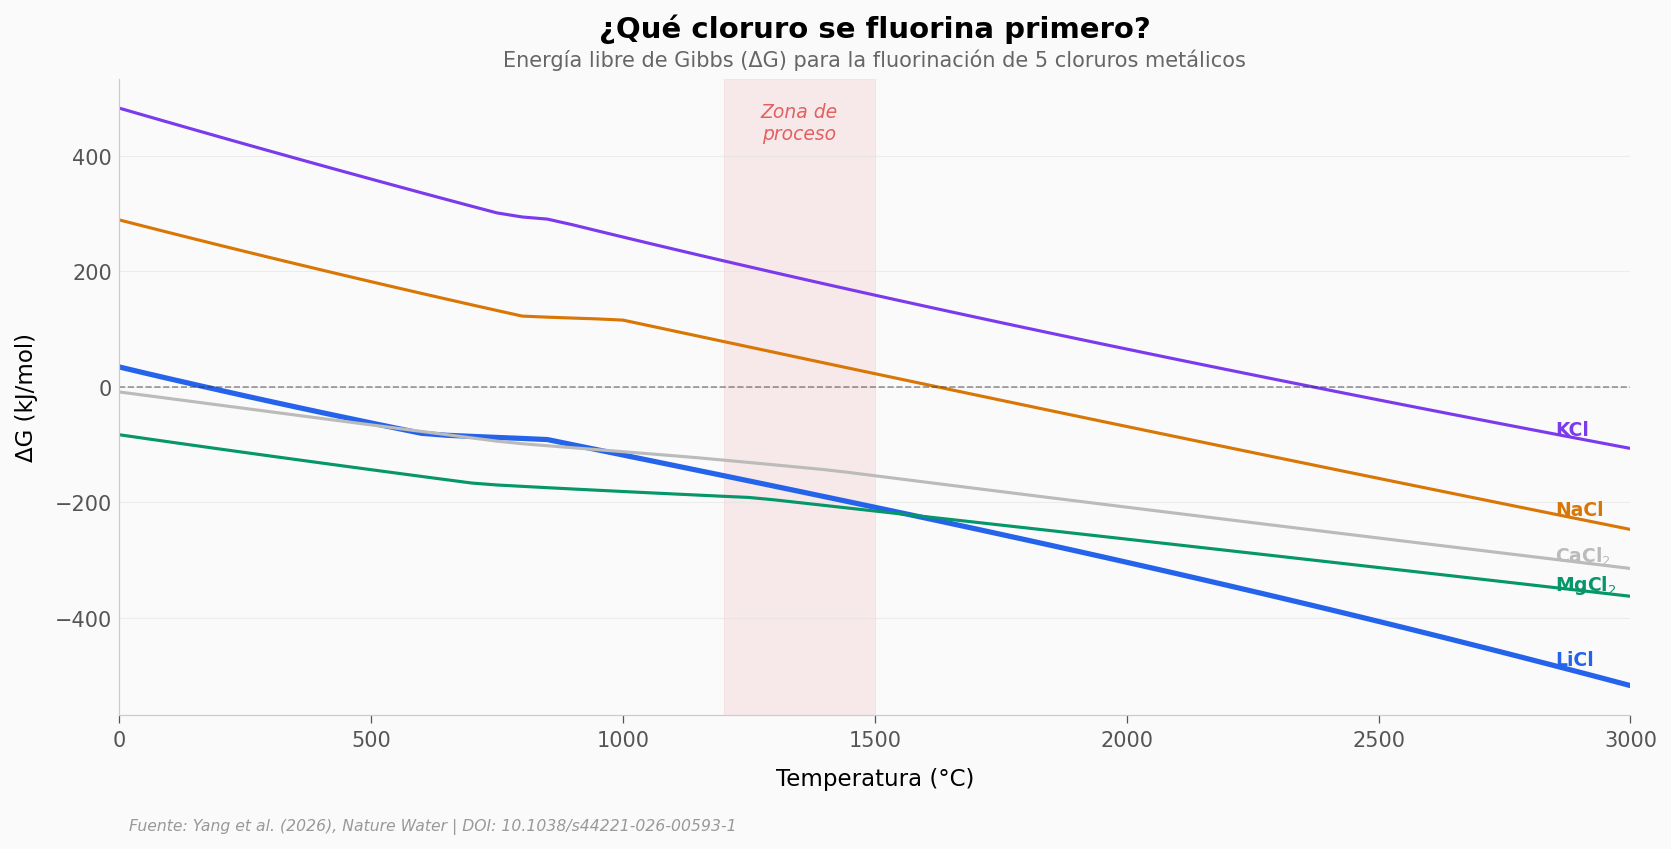

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

metals = [
    ('dg_licl_kj_mol', 'LiCl', COLOR_LITIO, 2.5),
    ('dg_nacl_kj_mol', 'NaCl', COLOR_SODIO, 1.5),
    ('dg_kcl_kj_mol', 'KCl', COLOR_POTASIO, 1.5),
    ('dg_mgcl2_kj_mol', 'MgCl$_2$', COLOR_MAGNESIO, 1.5),
    ('dg_cacl2_kj_mol', 'CaCl$_2$', COLOR_CALCIO, 1.5),
]

for col, label, color, lw in metals:
    ax.plot(dg['temperatura_c'], dg[col], color=color, linewidth=lw, label=label)

# Línea ΔG = 0
ax.axhline(y=0, color='#333333', linewidth=0.8, linestyle='--', alpha=0.5)

# Zona de proceso (~100V = 1.356°C)
ax.axvspan(1200, 1500, alpha=0.08, color=COLOR_ALERTA, zorder=0)
ax.text(1350, 430, 'Zona de\nproceso', fontsize=9, color=COLOR_ALERTA,
        ha='center', alpha=0.7, style='italic')

# Inline labels (al final de cada línea)
label_x = 2800
for col, label, color, _ in metals:
    y = dg[dg['temperatura_c'] == 2800][col].values[0]
    ax.text(label_x + 50, y, label, fontsize=9, color=color, fontweight='bold', va='center')

ax.set_title('¿Qué cloruro se fluorina primero?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Energía libre de Gibbs (ΔG) para la fluorinación de 5 cloruros metálicos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Temperatura (°C)', fontsize=11)
ax.set_ylabel('ΔG (kJ/mol)', fontsize=11)
ax.set_xlim(0, 3000)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/termodinamica_dg.png', dpi=200, bbox_inches='tight')
plt.show()

Todo lo que cae por debajo de la línea punteada (ΔG < 0) se fluorina espontáneamente. El MgCl₂ y el CaCl₂ siempre están abajo — se fluorinan a cualquier temperatura. El LiCl cruza la línea a unos 170 °C: a partir de ahí, también se fluorina.

¿Y el sodio y el potasio? Sus líneas arrancan muy arriba. El NaCl no baja de cero hasta los ~1.625 °C, y el KCl necesita aún más (~2.370 °C). Esa ventana de más de 1.400 °C entre LiCl y NaCl es donde el litio se fluorina y el sodio no. Ahí está la selectividad termodinámica.

Pero hay un matiz: MgCl₂ y CaCl₂ *también* se fluorinan. La separación del litio respecto a magnesio y calcio no viene de la termodinámica — viene de la solubilidad.

## ¿Y los PFAS? ¿De verdad se destruyen?

El proceso usa espuma contra incendios (AFFF) absorbida en carbón activado como agente fluorinante. La pregunta obvia: ¿se destruyen todos los tipos de PFAS, o solo algunos?

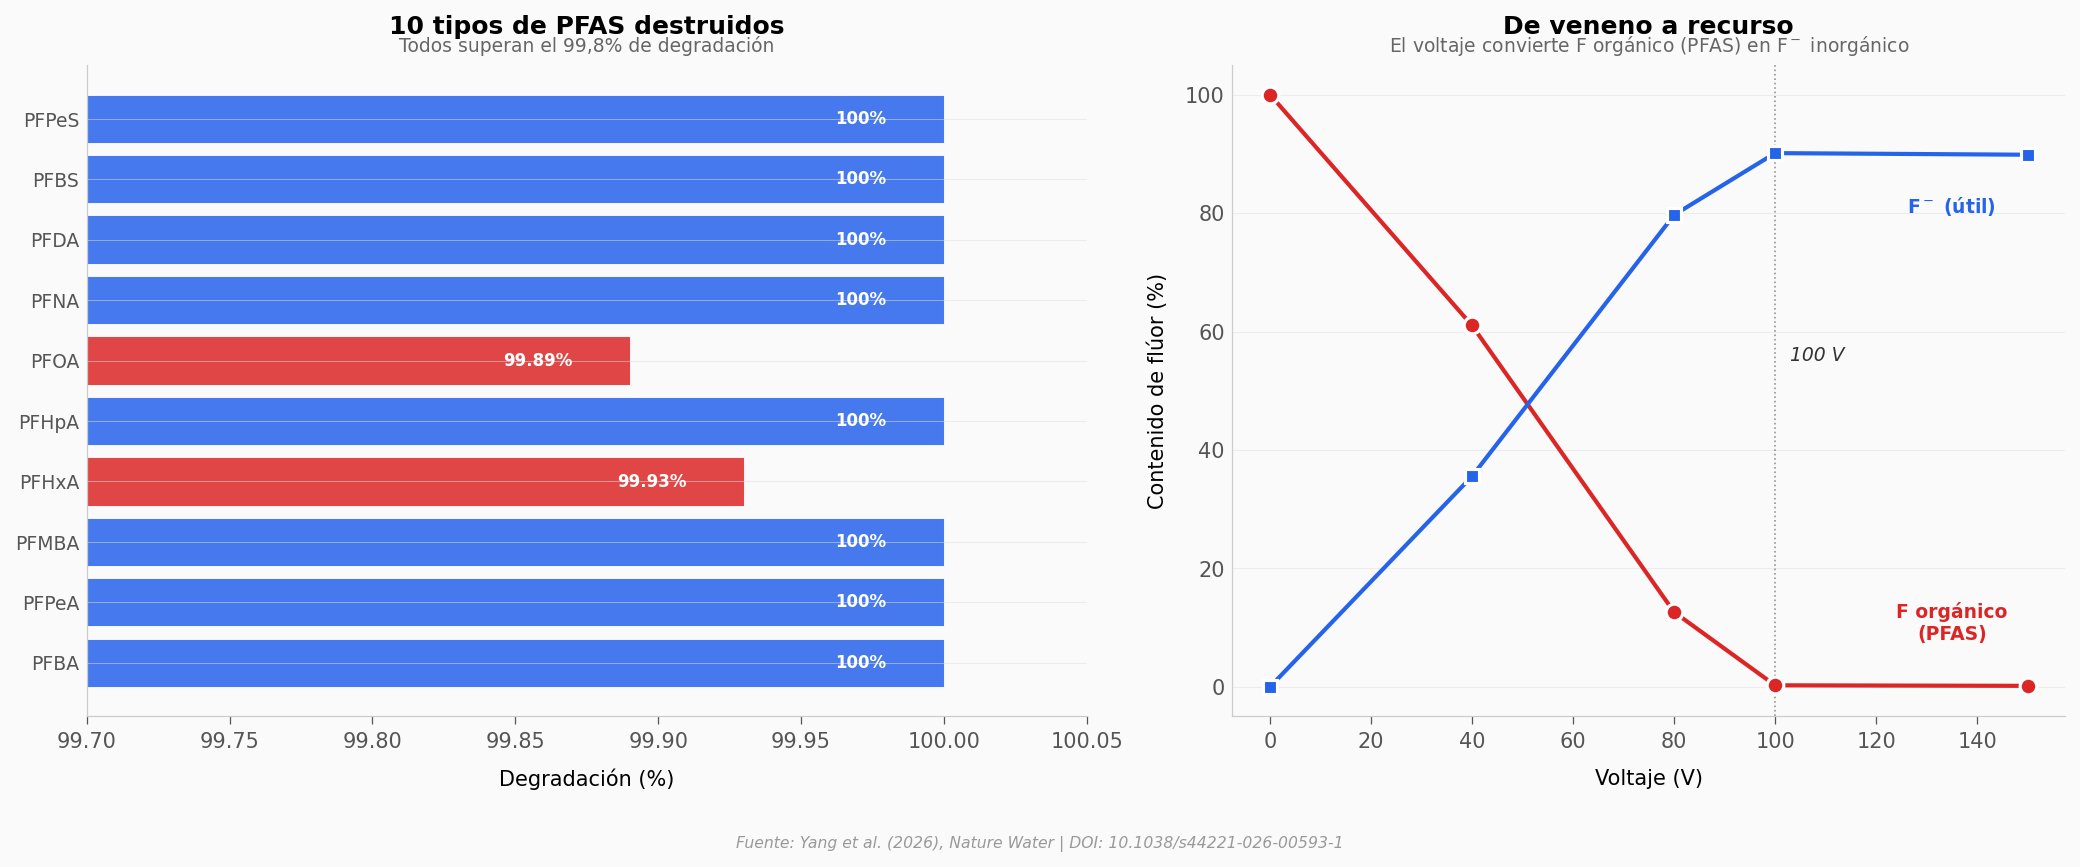

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'width_ratios': [1.2, 1]})

# ── Panel izquierdo: degradación por tipo de PFAS ──
colors_pfas = [COLOR_ALERTA if d < 100 else COLOR_LITIO for d in pfas['degradacion_pct']]
bars = ax1.barh(range(len(pfas)), pfas['degradacion_pct'], color=colors_pfas, alpha=0.85,
                edgecolor='white', linewidth=0.5)
ax1.set_yticks(range(len(pfas)))
ax1.set_yticklabels(pfas['tipo_pfas'], fontsize=9)
ax1.set_xlim(99.7, 100.05)
ax1.set_xlabel('Degradación (%)', fontsize=10)

# Inline labels
for i, (_, row) in enumerate(pfas.iterrows()):
    val = row['degradacion_pct']
    label = '100%' if val == 100 else f'{val:.2f}%'
    ax1.text(val - 0.02, i, label, va='center', ha='right', fontsize=8,
             color='white', fontweight='bold')

ax1.set_title('10 tipos de PFAS destruidos',
              fontsize=12, fontweight='bold', pad=15)
ax1.text(0.5, 1.02, 'Todos superan el 99,8% de degradación',
         transform=ax1.transAxes, fontsize=9, color='#666666', ha='center')

# ── Panel derecho: conversión de F orgánico por voltaje ──
ax2.plot(vf['voltaje_v'], vf['f_organico_pct'], color=COLOR_ALERTA, linewidth=2,
         marker='o', markersize=8, markerfacecolor=COLOR_ALERTA, markeredgecolor='white',
         markeredgewidth=1.5, label='F orgánico', zorder=5)
ax2.plot(vf['voltaje_v'], vf['f_inorganico_pct'], color=COLOR_LITIO, linewidth=2,
         marker='s', markersize=7, markerfacecolor=COLOR_LITIO, markeredgecolor='white',
         markeredgewidth=1.5, label='F$^-$ (útil)', zorder=5)

# Marca 100V
ax2.axvline(x=VOLTAJE_PROCESO, color='#333333', linewidth=0.8, linestyle=':', alpha=0.5)
ax2.text(VOLTAJE_PROCESO + 3, 55, f'{VOLTAJE_PROCESO} V', fontsize=9, color='#333333', style='italic')

# Inline labels
ax2.text(135, 8, 'F orgánico\n(PFAS)', fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='center')
ax2.text(135, 80, 'F$^-$ (útil)', fontsize=9, color=COLOR_LITIO, fontweight='bold', ha='center')

ax2.set_xlabel('Voltaje (V)', fontsize=10)
ax2.set_ylabel('Contenido de flúor (%)', fontsize=10)
ax2.set_title('De veneno a recurso',
              fontsize=12, fontweight='bold', pad=15)
ax2.text(0.5, 1.02, 'El voltaje convierte F orgánico (PFAS) en F$^-$ inorgánico',
         transform=ax2.transAxes, fontsize=9, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.5, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic', ha='center')
plt.savefig('figuras/pfas_degradacion.png', dpi=200, bbox_inches='tight')
plt.show()

Los 10 tipos de PFAS se degradan por encima del 99,8%. El PFOA — uno de los más preocupantes por su persistencia — llega al 99,89%. A 100 V, el flúor orgánico (el que hace a los PFAS indestructibles) baja del 100% al 0,26%. Ese flúor ahora es F⁻ inorgánico: un reactivo, no un contaminante.

## ¿Cuánto litio se recupera?

El proceso fluorina los cloruros de la salmuera. Luego, un lavado con fluoruro de amonio (NH₄F) disuelve selectivamente el LiF y lo separa de otros fluoruros menos solubles. ¿Funciona cuando el sodio domina la salmuera?

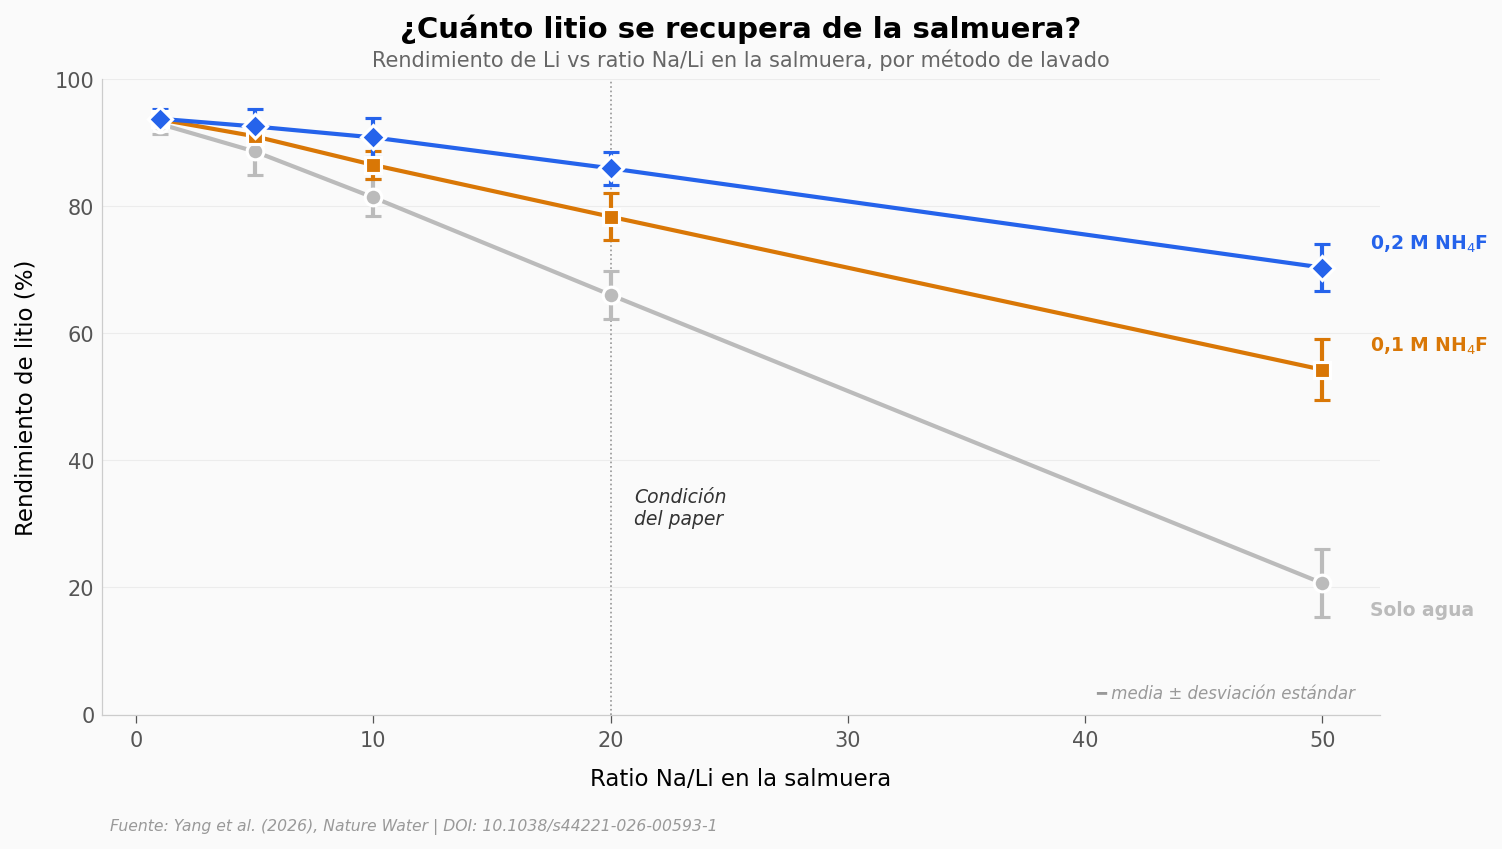

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))

methods = [
    ('yield_agua_pct', 'yield_agua_std', 'Solo agua', '#BBBBBB', 'o'),
    ('yield_nh4f_01m_pct', 'yield_nh4f_01m_std', '0,1 M NH$_4$F', COLOR_SODIO, 's'),
    ('yield_nh4f_02m_pct', 'yield_nh4f_02m_std', '0,2 M NH$_4$F', COLOR_LITIO, 'D'),
]

for ycol, errcol, label, color, marker in methods:
    ax.errorbar(li['ratio_na_li'], li[ycol], yerr=li[errcol],
                color=color, linewidth=2, marker=marker, markersize=8,
                markerfacecolor=color, markeredgecolor='white', markeredgewidth=1.5,
                capsize=4, capthick=1.2, label=label, zorder=5)

# Zona Na/Li=20 (condición paper)
ax.axvline(x=20, color='#333333', linewidth=0.8, linestyle=':', alpha=0.5)
ax.text(21, 30, 'Condición\ndel paper', fontsize=9, color='#333333', style='italic')

# Inline labels (al final de cada línea)
ax.text(52, li[li['ratio_na_li']==50]['yield_nh4f_02m_pct'].values[0] + 3,
        '0,2 M NH$_4$F', fontsize=9, color=COLOR_LITIO, fontweight='bold')
ax.text(52, li[li['ratio_na_li']==50]['yield_nh4f_01m_pct'].values[0] + 3,
        '0,1 M NH$_4$F', fontsize=9, color=COLOR_SODIO, fontweight='bold')
ax.text(52, li[li['ratio_na_li']==50]['yield_agua_pct'].values[0] - 5,
        'Solo agua', fontsize=9, color='#BBBBBB', fontweight='bold')

ax.set_title('¿Cuánto litio se recupera de la salmuera?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Rendimiento de Li vs ratio Na/Li en la salmuera, por método de lavado',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Ratio Na/Li en la salmuera', fontsize=11)
ax.set_ylabel('Rendimiento de litio (%)', fontsize=11)
ax.set_ylim(0, 100)
ax.text(0.98, 0.02, '━ media ± desviación estándar', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rendimiento_litio.png', dpi=200, bbox_inches='tight')
plt.show()

A medida que sube el ratio Na/Li (más sodio, menos litio — como en salmueras reales), el rendimiento cae. Pero con NH₄F al 0,2 M, incluso a Na/Li = 50 se recupera el 70,3% del litio. Sin NH₄F, a ese mismo ratio solo se rescata el 20,7%.

En la condición del paper (Na/Li = 20), el lavado con NH₄F sube el rendimiento de 66% a 86% — casi 20 puntos porcentuales más.

## ¿Por qué el litio se separa del resto?

La clave es la solubilidad. Después de la fluorinación, todo son fluoruros. Pero no todos se disuelven igual.

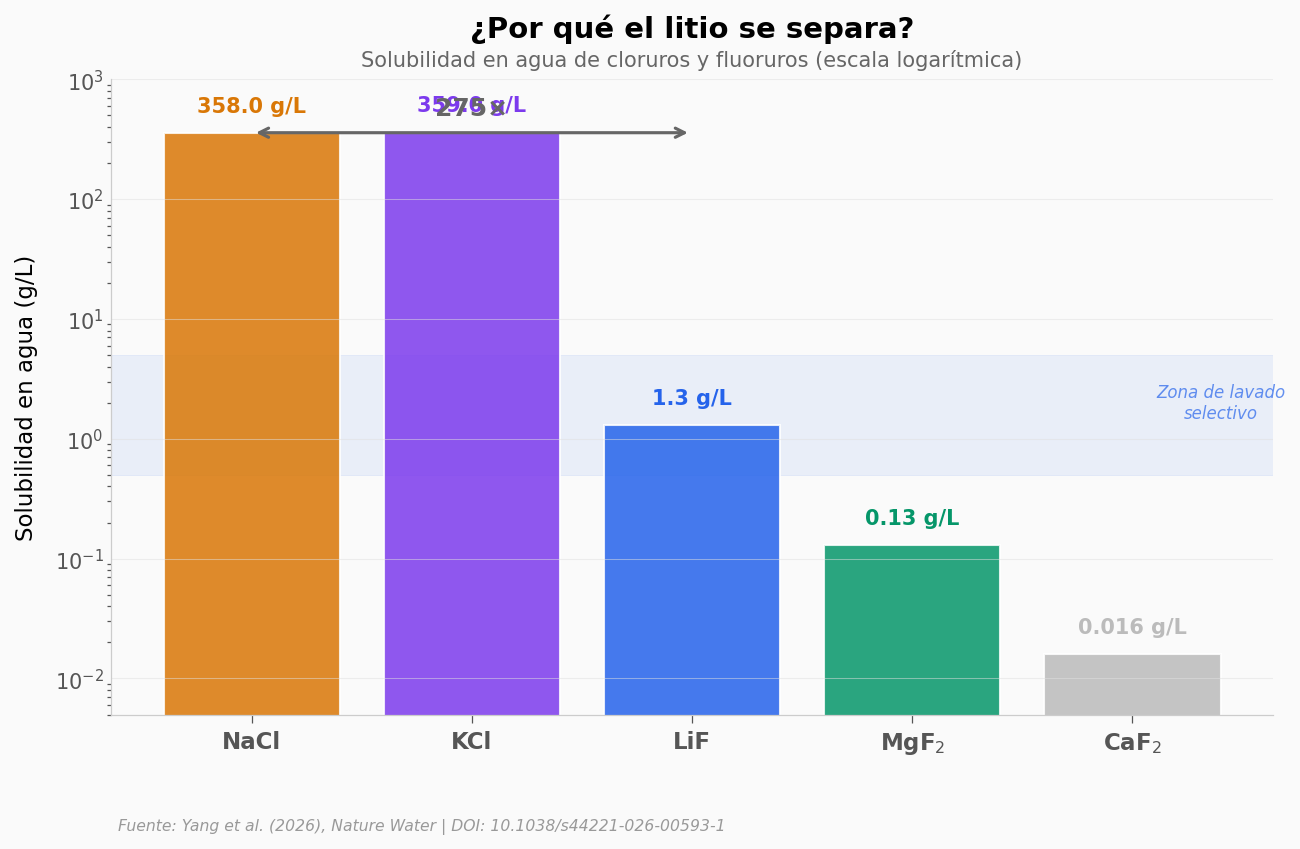

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))

compounds = sol['compuesto'].values
solubilities = sol['solubilidad_g_L'].values

# Colores por compuesto
color_map = {'NaCl': COLOR_SODIO, 'KCl': COLOR_POTASIO,
              'LiF': COLOR_LITIO, 'MgF2': COLOR_MAGNESIO, 'CaF2': COLOR_CALCIO}
colors = [color_map[c] for c in compounds]

bars = ax.bar(range(len(compounds)), solubilities, color=colors, alpha=0.85,
              edgecolor='white', linewidth=1)

# Escala log para ver las diferencias
ax.set_yscale('log')
ax.set_ylim(0.005, 1000)

# Inline labels
for i, (comp, sval) in enumerate(zip(compounds, solubilities)):
    y_label = sval * 1.5
    ax.text(i, y_label, f'{sval} g/L', ha='center', fontsize=10, fontweight='bold',
            color=color_map[comp])

# Etiquetas X
labels_es = ['NaCl', 'KCl', 'LiF', 'MgF$_2$', 'CaF$_2$']
ax.set_xticks(range(len(compounds)))
ax.set_xticklabels(labels_es, fontsize=11, fontweight='bold')

# Flecha bidireccional NaCl vs LiF
ax.annotate('', xy=(0, 358), xytext=(2, 358),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(1, 500, '275×', ha='center', fontsize=12, fontweight='bold', color='#666666')

# Zona de lavado
ax.axhspan(0.5, 5, alpha=0.08, color=COLOR_LITIO, zorder=0)
ax.text(4.4, 1.5, 'Zona de lavado\nselectivo', fontsize=8, color=COLOR_LITIO,
        ha='center', style='italic', alpha=0.7)

ax.set_title('¿Por qué el litio se separa?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Solubilidad en agua de cloruros y fluoruros (escala logarítmica)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Solubilidad en agua (g/L)', fontsize=11)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/solubilidad_fluoruros.png', dpi=200, bbox_inches='tight')
plt.show()

El NaCl y el KCl son súper solubles (~358 g/L). En la salmuera original, compiten con el litio. Pero después de la fluorinación, el LiF tiene una solubilidad de solo 1,3 g/L — 275 veces menos que el NaCl. Y el MgF₂ (0,13 g/L) y CaF₂ (0,016 g/L) son prácticamente insolubles.

Ese es el truco: al fluorinar, el litio pasa de ser uno más entre los solubles a estar en una ventana intermedia. Se disuelve lo suficiente para lavarlo, pero precipita selectivamente con el agente correcto (NH₄F).

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|--------|
| 10 tipos de PFAS se degradan >99,8% | ✅ | n = 10, mínimo 99,89% (PFOA), 8/10 al 100% exacto |
| A 100 V el F orgánico cae al 0,26% | ✅ | Dato directo de Fig. 1f — conversión casi completa |
| Rendimiento de Li ~86% con NH₄F 0,2 M (Na/Li = 20) | ✅ | 85,98% ± 2,62% — consistente con ~82% del paper (que incluye pasos adicionales) |
| LiF 275× menos soluble que NaCl | ✅ | 1,3 vs 358 g/L — dato de referencia termodinámico |
| El LCA sugiere reducción de emisiones vs extracción industrial | ⚠️ | El abstract dice "indicate" (T2) — los datos LCA están en el supplementary pero dependen de supuestos del modelo |

> **Limitaciones:** Los datos son de escala de laboratorio (10 kg de precursor). El escalado industrial puede cambiar rendimientos y costos. El LCA asume precios y tasas de electricidad de Texas. La comparación con métodos industriales usa datos de modelos (GREET), no mediciones directas.

---

## Ahora tú

1. **¿Qué pasa a Na/Li = 100?** El dato más extremo es Na/Li = 50. ¿Puedes extrapolar la tendencia? Prueba con `np.polyfit` sobre los datos de 0,2 M NH₄F.

2. **¿Cuál es la ventana termodinámica real?** Busca a qué temperatura el NaCl cruza ΔG = 0. ¿Cuántos grados de selectividad hay entre LiCl y NaCl?

3. **¿Cuánto flúor se "pierde"?** A 100 V, el F total baja de 100% a 90,4%. ¿A dónde va el 9,6% restante? (Pista: se volatiliza como gas)

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Ventana de selectividad termodinámica: ¿cuántos grados entre LiCl y NaCl?

# Encontrar la temperatura donde cada cloruro cruza ΔG = 0
from scipy.interpolate import interp1d

for col, nombre in [('dg_licl_kj_mol', 'LiCl'), ('dg_nacl_kj_mol', 'NaCl'), ('dg_kcl_kj_mol', 'KCl')]:
    f_interp = interp1d(dg[col], dg['temperatura_c'])
    try:
        t_zero = float(f_interp(0))
        print(f"{nombre} cruza ΔG = 0 a: {t_zero:.0f} °C")
    except ValueError:
        print(f"{nombre}: ΔG nunca cruza 0 en el rango de datos")

# Ventana de selectividad
t_licl = float(interp1d(dg['dg_licl_kj_mol'], dg['temperatura_c'])(0))
t_nacl = float(interp1d(dg['dg_nacl_kj_mol'], dg['temperatura_c'])(0))
print(f"\nVentana de selectividad Li vs Na: {t_nacl - t_licl:.0f} °C")
print(f"  (LiCl se fluorina a {t_licl:.0f} °C, NaCl recién a {t_nacl:.0f} °C)")

LiCl cruza ΔG = 0 a: 171 °C
NaCl cruza ΔG = 0 a: 1625 °C
KCl cruza ΔG = 0 a: 2370 °C

Ventana de selectividad Li vs Na: 1454 °C
  (LiCl se fluorina a 171 °C, NaCl recién a 1625 °C)


---

## Créditos

- **Paper:** Yang, Y. et al. (2026). Electrothermal fluorination of PFAS for lithium recovery from brine. *Nature Water*. DOI: [10.1038/s44221-026-00593-1](https://doi.org/10.1038/s44221-026-00593-1)
- **Datos:** Supplementary Information (Source Data), descargados de Nature Water
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com)
- **Licencia notebook:** [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/)